In [56]:
# === Setup ===
import pandas as pd
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.model_selection import train_test_split

# Parameters
sequence_length = 30
forecast_day = pd.to_datetime("2025-04-30")
cutoff_date = forecast_day - pd.Timedelta(days=7)

# Load data
df = pd.read_csv(r"C:\Users\jaskew\Documents\project_repository\notebooks\observationEventForecasting\DataPreprocessing\FullIndicatorMatrix.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['indicator', 'date']).reset_index(drop=True)

# Get all indicators (or use .index[:N] for top N)
indicators_to_run = df['indicator'].value_counts().index

# === Store forecast results ===
results = []

# === Run LSTM forecast per indicator ===
for indicator_id in indicators_to_run:
    data = df[df['indicator'] == indicator_id].sort_values('date').reset_index(drop=True)
    past_data = data[data['date'] < cutoff_date]

    if len(past_data) < sequence_length + 1:
        continue

    # Build training sequences
    X, y = [], []
    for i in range(len(past_data) - sequence_length):
        X.append(past_data['seen'].iloc[i:i+sequence_length].values)
        y.append(past_data['seen'].iloc[i + sequence_length])

    X = np.array(X).astype(np.float32).reshape((-1, sequence_length, 1))
    y = np.array(y).astype(np.float32)

    # Train LSTM
    X_train, _, y_train, _ = train_test_split(X, y, test_size=0.1, random_state=42)
    model = Sequential([
        LSTM(32, input_shape=(sequence_length, 1)),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy')
    model.fit(X_train, y_train, epochs=10, batch_size=8, verbose=0)

    # Predict using most recent 30 days
    latest_seq = past_data['seen'].iloc[-sequence_length:].values.reshape(1, sequence_length, 1).astype(np.float32)
    prediction_prob = model.predict(latest_seq)[0][0]
    prediction = int(prediction_prob > 0.5)

    # Store in DataFrame
    results.append({
        "Indicator": indicator_id,
        "Forecast Date": forecast_day.date(),
        "Predicted Seen": "Yes" if prediction else "No",
        "Confidence": round(prediction_prob, 3)
    })

# === Final result ===
results_df = pd.DataFrame(results)
results_df


C:\Users\jaskew\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 484ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

,Indicator,Forecast Date,Predicted Seen,Confidence
0,102.90.61.13,2025-04-30,No,0.018
1,102.91.94.193,2025-04-30,No,0.024
2,103.149.249.226,2025-04-30,No,0.020
3,103.225.136.166,2025-04-30,No,0.020
4,104.128.161.233,2025-04-30,No,0.312
...,...,...,...,...
216,www.3u.com,2025-04-30,No,0.008
217,www.deepseek.com,2025-04-30,Yes,0.816
218,www.deepseek.com.cdn.cloudflare.net,2025-04-30,Yes,0.922
219,www.filemail.com,2025-04-30,No,0.098


In [57]:
predicted_seen = results_df[results_df['Predicted Seen'] == 'Yes']
predicted_seen.columns = predicted_seen.columns.str.lower()
predicted_seen

,indicator,forecast date,predicted seen,confidence
6,104.18.32.191,2025-04-30,Yes,0.787
13,118.193.59.10,2025-04-30,Yes,0.932
14,118.193.72.187,2025-04-30,Yes,0.838
24,146.70.45.166,2025-04-30,Yes,0.843
36,162.142.125.242,2025-04-30,Yes,0.851
37,162.142.125.255,2025-04-30,Yes,0.799
38,162.241.225.237,2025-04-30,Yes,0.707
47,172.240.108.68,2025-04-30,Yes,0.805
48,172.98.33.195,2025-04-30,Yes,0.849
56,185.129.62.63,2025-04-30,Yes,0.522


In [58]:
current_seen_data = df[(df['date'] == '2025-04-30') & (df['seen'] == 1)]
current_seen_data

,API_UserName,date,indicator,observations,dayofweek,is_weekend,day,month,seen
599,74198686107399967946,2025-04-30,104.128.161.233,7,2,False,30,4,1
839,74198686107399967946,2025-04-30,104.18.32.191,2,2,False,30,4,1
1679,74198686107399967946,2025-04-30,118.193.59.10,1,2,False,30,4,1
1799,74198686107399967946,2025-04-30,118.193.72.187,8,2,False,30,4,1
2999,74198686107399967946,2025-04-30,146.70.45.166,11,2,False,30,4,1
3119,74198686107399967946,2025-04-30,149.102.229.181,5,2,False,30,4,1
4439,74198686107399967946,2025-04-30,162.142.125.242,31,2,False,30,4,1
4559,74198686107399967946,2025-04-30,162.142.125.255,22,2,False,30,4,1
5159,74198686107399967946,2025-04-30,169.150.223.208,1,2,False,30,4,1
5759,74198686107399967946,2025-04-30,172.240.108.68,25,2,False,30,4,1


In [59]:
missed_indicators = predicted_seen.merge(
    current_seen_data,
    how='outer',
    on='indicator',
    indicator=True
)
missed_indicators = missed_indicators[missed_indicators['_merge'] != 'both']
missed_indicators

,indicator,forecast date,predicted seen,confidence,API_UserName,date,observations,dayofweek,is_weekend,day,month,seen,_merge
0,104.128.161.233,NaN,NaN,NaN,74198686107399967946,2025-04-30,7.0,2.0,False,30.0,4.0,1.0,right_only
5,149.102.229.181,NaN,NaN,NaN,74198686107399967946,2025-04-30,5.0,2.0,False,30.0,4.0,1.0,right_only
8,162.241.225.237,2025-04-30,Yes,0.707,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,left_only
9,169.150.223.208,NaN,NaN,NaN,74198686107399967946,2025-04-30,1.0,2.0,False,30.0,4.0,1.0,right_only
13,185.220.100.240,2025-04-30,Yes,0.858,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,left_only
15,190.92.174.36,NaN,NaN,NaN,74198686107399967946,2025-04-30,4.0,2.0,False,30.0,4.0,1.0,right_only
16,192.124.249.112,NaN,NaN,NaN,74198686107399967946,2025-04-30,14.0,2.0,False,30.0,4.0,1.0,right_only
17,194.180.49.218,2025-04-30,Yes,0.602,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,left_only
18,194.180.49.219,2025-04-30,Yes,0.551,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,left_only
19,194.180.49.70,2025-04-30,Yes,0.831,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,left_only


In [60]:
false_positives = missed_indicators[missed_indicators['_merge'] == 'left_only']
false_positives

,indicator,forecast date,predicted seen,confidence,API_UserName,date,observations,dayofweek,is_weekend,day,month,seen,_merge
8,162.241.225.237,2025-04-30,Yes,0.707,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,left_only
13,185.220.100.240,2025-04-30,Yes,0.858,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,left_only
17,194.180.49.218,2025-04-30,Yes,0.602,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,left_only
18,194.180.49.219,2025-04-30,Yes,0.551,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,left_only
19,194.180.49.70,2025-04-30,Yes,0.831,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,left_only
20,194.180.49.71,2025-04-30,Yes,0.720,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,left_only
35,63.143.57.180,2025-04-30,Yes,0.813,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,left_only
37,6sigma.us,2025-04-30,Yes,0.826,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,left_only
43,chriswrightmd@yahoo.com,2025-04-30,Yes,0.503,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,left_only


In [61]:
false_negatives = missed_indicators[missed_indicators['_merge'] == 'right_only']
false_negatives

,indicator,forecast date,predicted seen,confidence,API_UserName,date,observations,dayofweek,is_weekend,day,month,seen,_merge
0,104.128.161.233,NaN,NaN,NaN,74198686107399967946,2025-04-30,7.0,2.0,False,30.0,4.0,1.0,right_only
5,149.102.229.181,NaN,NaN,NaN,74198686107399967946,2025-04-30,5.0,2.0,False,30.0,4.0,1.0,right_only
9,169.150.223.208,NaN,NaN,NaN,74198686107399967946,2025-04-30,1.0,2.0,False,30.0,4.0,1.0,right_only
15,190.92.174.36,NaN,NaN,NaN,74198686107399967946,2025-04-30,4.0,2.0,False,30.0,4.0,1.0,right_only
16,192.124.249.112,NaN,NaN,NaN,74198686107399967946,2025-04-30,14.0,2.0,False,30.0,4.0,1.0,right_only
21,198.38.84.58,NaN,NaN,NaN,74198686107399967946,2025-04-30,7.0,2.0,False,30.0,4.0,1.0,right_only
22,198.44.129.99,NaN,NaN,NaN,74198686107399967946,2025-04-30,55.0,2.0,False,30.0,4.0,1.0,right_only
23,216.151.180.16,NaN,NaN,NaN,74198686107399967946,2025-04-30,4.0,2.0,False,30.0,4.0,1.0,right_only
30,45.84.107.128,NaN,NaN,NaN,74198686107399967946,2025-04-30,9.0,2.0,False,30.0,4.0,1.0,right_only
33,51.89.138.221,NaN,NaN,NaN,74198686107399967946,2025-04-30,1.0,2.0,False,30.0,4.0,1.0,right_only


In [62]:
false_negatives_activity = df[df['indicator'].isin(false_negatives['indicator'])]
false_positives_activity = df[df['indicator'].isin(false_positives['indicator'])]


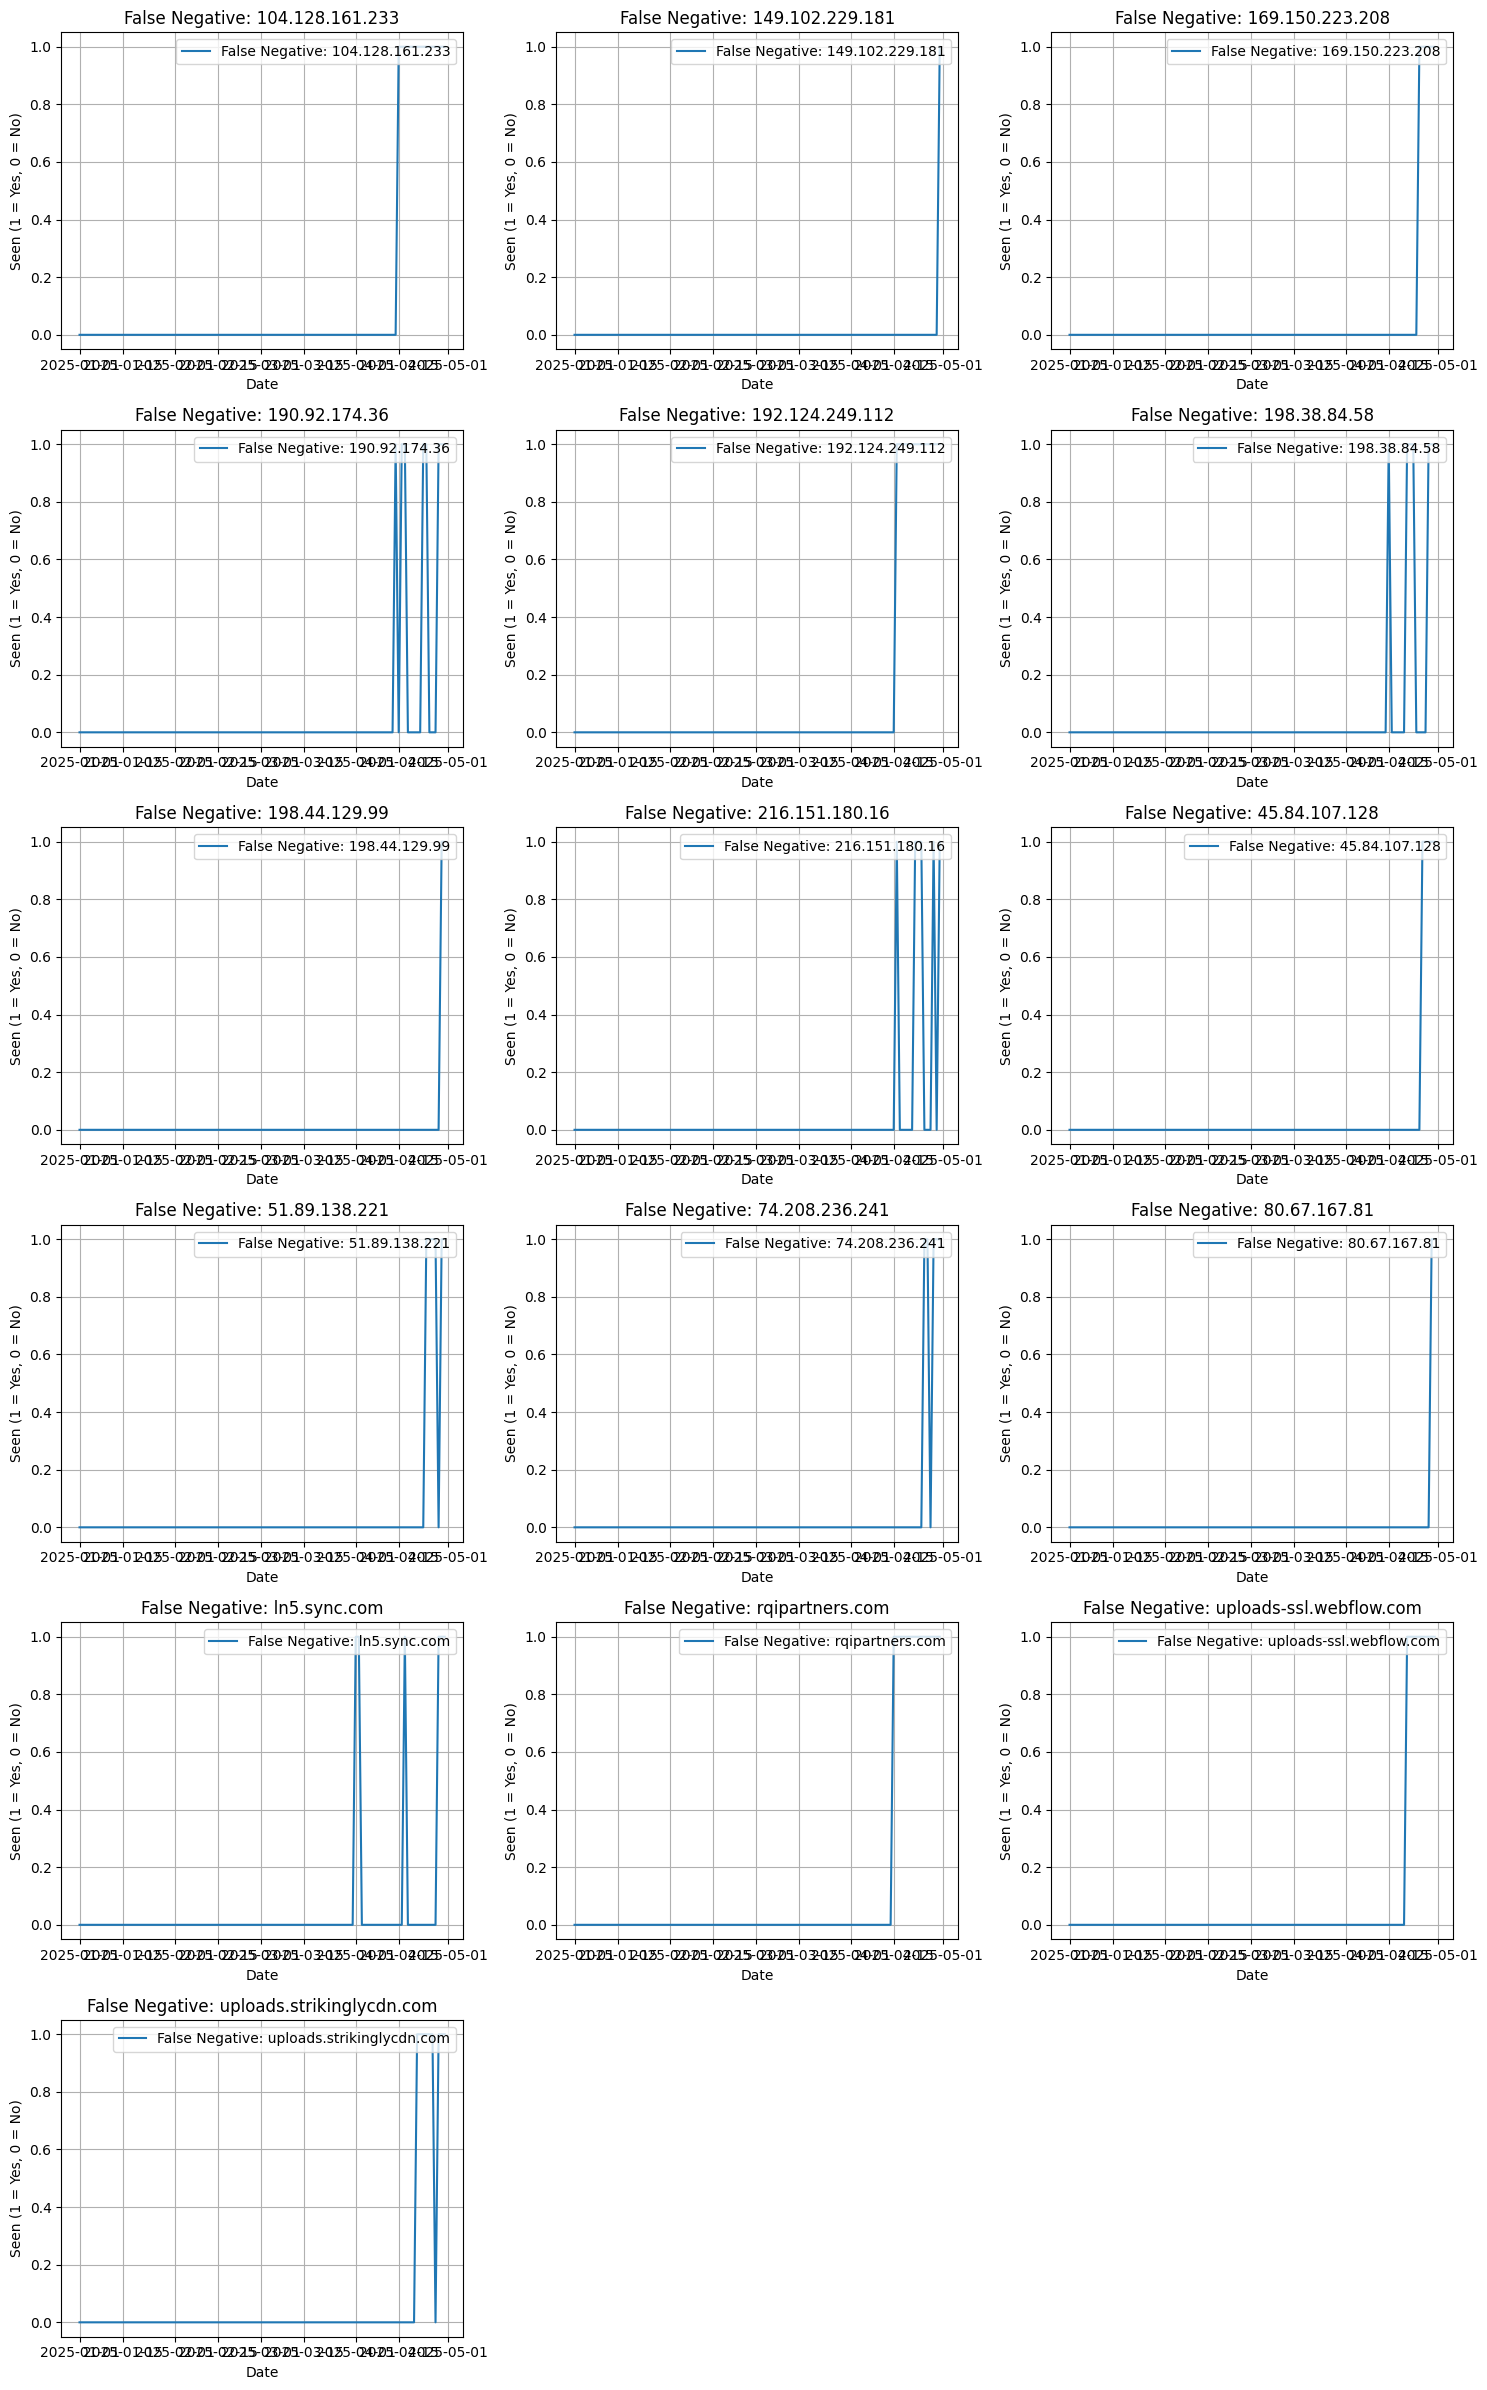

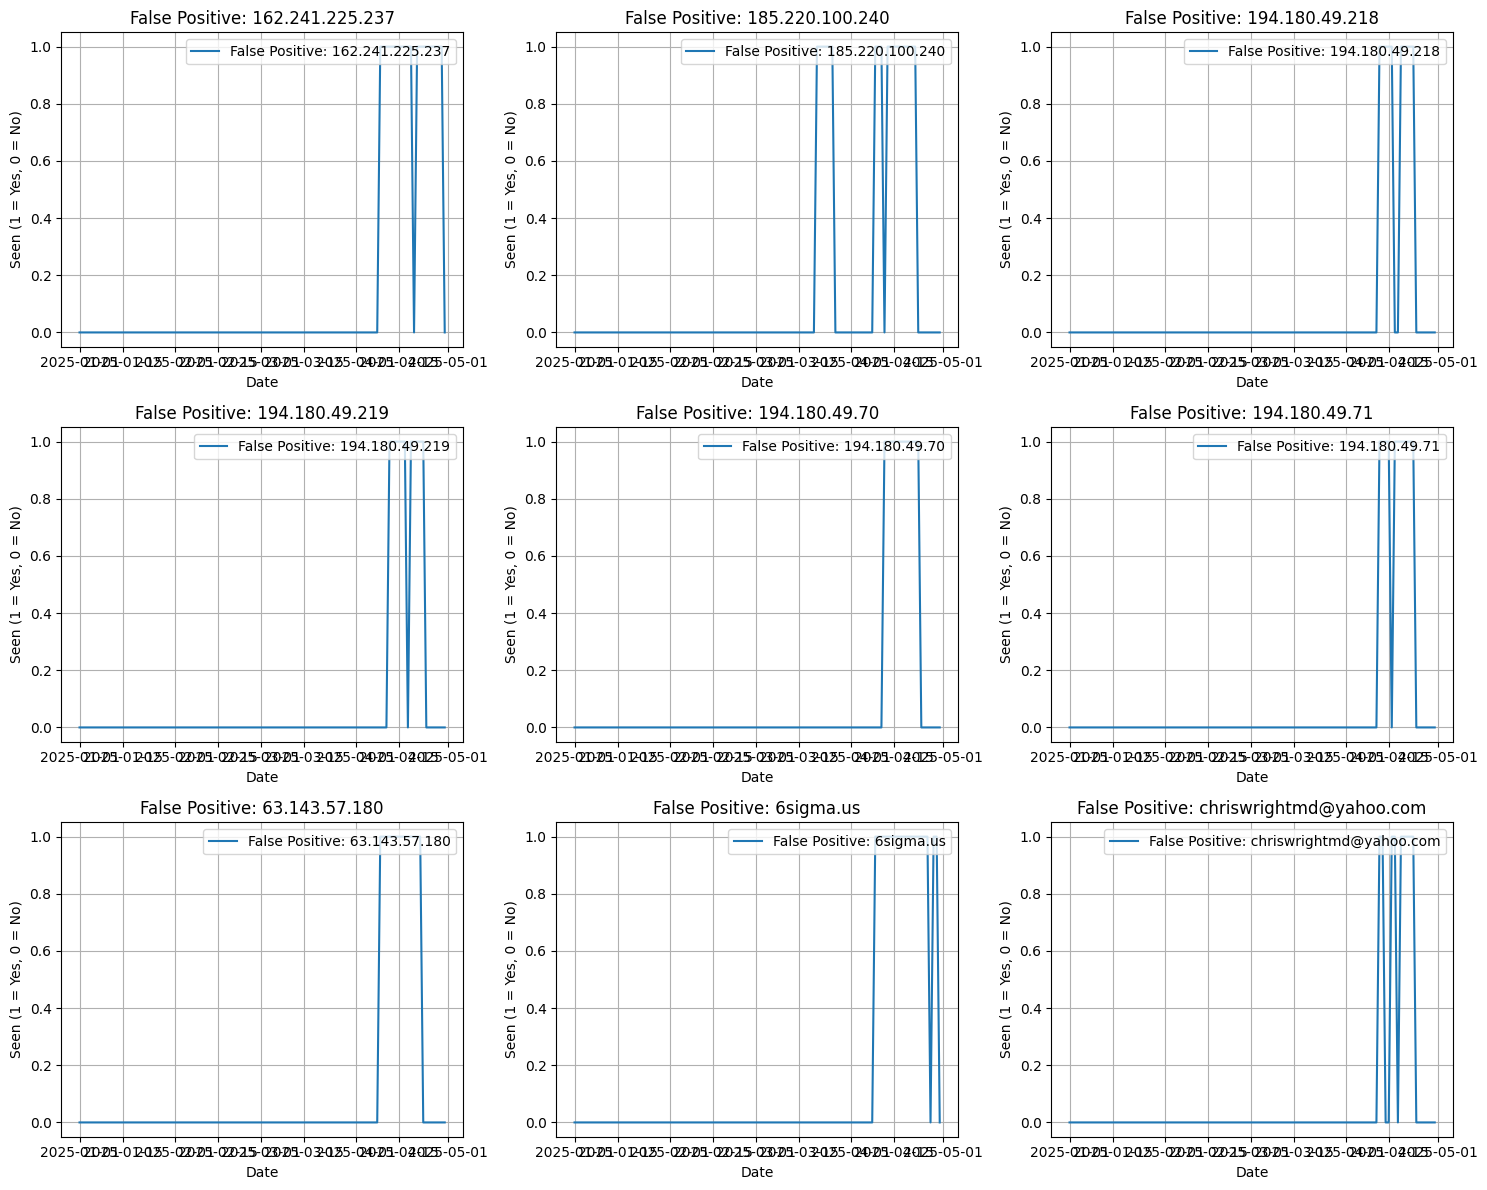

In [63]:
import matplotlib.pyplot as plt
import math

# Function to plot indicators in a grid
def plot_indicators_in_grid(activity_data, indicators, title_prefix):
    num_indicators = len(indicators)
    cols = 3  # Number of columns in the grid
    rows = math.ceil(num_indicators / cols)  # Calculate rows needed

    fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 4))
    axes = axes.flatten()  # Flatten the axes array for easy iteration

    for i, indicator in enumerate(indicators):
        ax = axes[i]
        indicator_data = activity_data[activity_data['indicator'] == indicator]
        ax.plot(indicator_data['date'], indicator_data['seen'], label=f'{title_prefix}: {indicator}')
        ax.set_title(f'{title_prefix}: {indicator}')
        ax.set_xlabel('Date')
        ax.set_ylabel('Seen (1 = Yes, 0 = No)')
        ax.legend(loc='upper right')
        ax.grid(True)

    # Hide any unused subplots
    for i in range(len(indicators), len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout()
    plt.show()

# Plot false positives in a grid
plot_indicators_in_grid(false_negatives_activity, false_negatives['indicator'].unique(), 'False Negative')
plot_indicators_in_grid(false_positives_activity, false_positives['indicator'].unique(), 'False Positive')

